### Generates a scatter plot of solver iterations vs. number of edges.

This script queries a benchmark database to get the number of iterations for each successful solver run and the number of edges for the corresponding problem. It then creates a scatter plot with a log-log scale.

In [111]:
import sqlite3
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.path import Path

In [112]:
def query_run_data(db_path):
    conn = sqlite3.connect(f"file:{db_path}?mode=ro", uri=True)
    query = """
    SELECT
        p.num_edges,
        r.iters,
        r.solver_name,
        c.precision
    FROM
        runs r
    JOIN
        problems p ON r.problem_id = p.id
    JOIN
        configs c ON r.config_id = c.id
    ORDER BY
        p.num_edges;
    """
    df = pl.read_database(query, conn)
    conn.close()
    print(f"Data loaded from database: {df}")
    return df

In [113]:
def grid_cell_marker(filled_idx, n=3, cell=1/3, gap=0.0):
    """
    Return a Path marker for an n×n grid with only one cell filled.

    The marker is normalized so its total bounding box is always [-0.5, 0.5]²,
    making the marker size 's' in scatter() behave consistently.
    """
    total = n * cell + (n - 1) * gap
    i, j = divmod(filled_idx, n)

    # origin (bottom-left) of the filled cell in raw units
    origin_x = -total / 2 + j * (cell + gap)
    origin_y = -total / 2 + (n - 1 - i) * (cell + gap)

    x0, y0 = origin_x, origin_y
    x1, y1 = x0 + cell, y0 + cell

    # define all corners of the total grid first (for bounding box)
    corner_anchors = [
        (-total / 2, -total / 2),
        (-total / 2,  total / 2),
        ( total / 2, -total / 2),
        ( total / 2,  total / 2),
    ]
    verts = []
    codes = []

    # ensure bounding box anchors (MOVETO-only)
    for ca in corner_anchors:
        verts.append(ca)
        codes.append(Path.MOVETO)

    # add polygon for filled cell
    verts += [(x0, y0), (x1, y0), (x1, y1), (x0, y1), (0.0, 0.0)]  # dummy for CLOSEPOLY
    codes += [Path.MOVETO, Path.LINETO, Path.LINETO, Path.LINETO, Path.CLOSEPOLY]

    # normalize to unit bbox [-0.5, 0.5]
    verts_norm = [((vx / total), (vy / total)) for vx, vy in verts]

    return Path(verts_norm, codes)

In [ ]:
def plot_iterations_vs_edges(db_path, solver_pattern=None):
    df = query_run_data(db_path)

    if df.is_empty():
        print("No data found matching the criteria.")
        return

    if solver_pattern:
        df = df.filter(pl.col("solver_name").str.contains(solver_pattern, strict=False))

    if df.is_empty():
        print(f"No data found after applying filters (solver_pattern='{solver_pattern}').")
        return

    df = df.with_columns([
        (pl.col("solver_name") + ", " + pl.col("precision")).alias("config_label")
    ])

    unique_configs = df["config_label"].unique().sort().to_list()
    colors = plt.get_cmap("Dark2", len(unique_configs))
    config_color_map = { config: colors(i) for i, config in enumerate(unique_configs) }

    fig, ax = plt.subplots(figsize=(12, 8), dpi=200)

    # collect positive values for global tick computation
    x_all = df["num_edges"].to_numpy()
    y_all = df["iters"].to_numpy()
    pos_mask = (x_all > 0) & (y_all > 0)
    if not pos_mask.any():
        print("No positive points to plot.")
        return
    x_all_log = np.log10(x_all[pos_mask])
    y_all_log = np.log10(y_all[pos_mask])

    # clamp y in original units
    y_min = 7
    y_max = 220
    y_min_log = np.log10(y_min)
    y_max_log = np.log10(y_max)

    # pre-create 9 markers (one per 3x3 cell) -- all cells use same geometric size
    grid_markers = [grid_cell_marker(i) for i in range(9)]

    # use a single uniform marker area for all grid-cell markers (points^2)
    # with normalized paths much smaller s values are visible; adjust to taste.
    uniform_marker_size = 30.0

    # plot per-config using manual log10 transform, clamp y to [y_min, y_max]
    for i_cfg, config_label in enumerate(unique_configs):
        config_df = df.filter(pl.col("config_label") == config_label)
        x = config_df["num_edges"].to_numpy()
        y = config_df["iters"].to_numpy()
        mask = (x > 0) & (y > 0)
        if not mask.any():
            continue
        y_clamped = np.clip(y[mask], y_min, y_max)

        # scatter point-by-point using different 3x3-grid markers (same geometric size)
        xs = np.log10(x[mask])
        ys = np.log10(y_clamped)
        for i_pt, (xp, yp) in enumerate(zip(xs, ys)):
            mk = grid_markers[i_cfg % len(grid_markers)]
            ax.scatter(
                xp,
                yp,
                label=None,                 # labels only once via legend below
                marker=mk,
                s=uniform_marker_size,      # uniform marker area for all cells
                facecolor=config_color_map[config_label],
                edgecolor="k",
                linewidths=0.25,
            )
        if len(xs) > 1:
            # Apply filter for fitting region
            x_min_fit = np.log10(1_000_000)   # example lower bound in original x units
            y_max_fit = np.log10(199)      # example upper bound in original y units

            fit_mask = (xs >= x_min_fit) & (ys <= y_max_fit)
            if np.count_nonzero(fit_mask) > 1:
                x_fit_range = np.linspace(xs[fit_mask].min(), xs[fit_mask].max(), 100)

                # (1) Linear fit (power-law): y = a * x^b
                coeffs_lin = np.polyfit(xs[fit_mask], ys[fit_mask], 1)
                slope, intercept = coeffs_lin
                a = 10**intercept
                b = slope
                y_fit_lin = slope * x_fit_range + intercept
                fit_label_lin = f"{config_label}\n  y = {a:.2e} · x^{b:.3f}"

                ax.plot(
                    x_fit_range, y_fit_lin,
                    color=config_color_map[config_label],
                    linewidth=1.0,
                    alpha=0.7,
                    label=fit_label_lin,
                )
        if len(xs) > 1:
            # Apply filter for fitting region
            y_max_fit = np.log10(199)      # example upper bound in original y units

            fit_mask = (ys <= y_max_fit)
            if np.count_nonzero(fit_mask) > 2:
                x_fit_range = np.linspace(xs[fit_mask].min(), xs[fit_mask].max(), 100)

                from scipy.optimize import minimize

                # (2) Smooth monotonic quadratic fit: log10(y) = c2·(log10(x))² + c1·log10(x) + c0
                x_fit = xs[fit_mask]
                y_fit = ys[fit_mask]

                # Initial unconstrained quadratic fit (as fallback/initial guess)
                c2_0, c1_0, c0_0 = np.polyfit(x_fit, y_fit, 2)

                # Objective: least-squares error
                def objective(c):
                    c2, c1, c0 = c
                    y_pred = c2 * x_fit**2 + c1 * x_fit + c0
                    return np.mean((y_pred - y_fit)**2)

                # Constraint: derivative ≥ 0 over the fitting range
                # d/dx [log10(y)] = 2*c2*x + c1 ≥ 0 for all x in [min(x_fit), max(x_fit)]
                x_min, x_max = x_fit.min(), x_fit.max()
                cons = [
                    {"type": "ineq", "fun": lambda c: 2*c[0]*x_min + c[1]},
                    {"type": "ineq", "fun": lambda c: 2*c[0]*x_max + c[1]},
                ]

                # Fit with positivity constraints
                res = minimize(objective, [c2_0, c1_0, c0_0], constraints=cons)
                c2, c1, c0 = res.x

                # Smooth monotonic quadratic
                x_fit_range = np.linspace(x_min, x_max, 200)
                y_fit_quad = c2 * x_fit_range**2 + c1 * x_fit_range + c0

                fit_label_quad = (
                    f"{config_label}\n  y = 10^({c2:.3e}·(log₁₀x)² + {c1:.3f}·log₁₀x + {c0:.3f})"
                )

                ax.plot(
                    x_fit_range, y_fit_quad,
                    color=config_color_map[config_label],
                    linestyle="--",
                    linewidth=1.0,
                    alpha=0.6,
                    label=fit_label_quad,
                )

    # build a legend by plotting one marker per config
    for config_label in unique_configs:
        ax.scatter([], [], marker=grid_markers[4], s=5*uniform_marker_size,
                   facecolor=config_color_map[config_label], edgecolor="k",
                   linewidths=0.25, alpha=0.85, label=config_label)

    # create tick positions in log-space but label them with actual (non-log) numbers
    def make_nice_ticks(log_vals, include=None):
        lo = np.floor(log_vals.min())
        hi = np.ceil(log_vals.max())

        # Use 1-2-5 ticks per decade for higher density and nicer spacing
        decades = np.arange(int(lo), int(hi) + 1)
        ticks = []
        for e in decades:
            for m in (1, 2, 5):
                ticks.append(e + np.log10(m))  # log10-position

        ticks = np.array(sorted(set(ticks)), dtype=float)

        # If the total span is < 1 decade, add extra linear ticks in log-space
        if hi - lo < 1:
            extra = np.linspace(lo, hi, num=9)
            ticks = np.unique(np.concatenate([ticks, extra]))

        # Build labels in original (non-log) units
        labels = [f"{int(round(10**t)):,}" for t in ticks]

        if include is not None:
            # ensure included log-values appear as ticks
            for v in include:
                if v not in ticks:
                    ticks = np.concatenate([ticks, [v]])
            order = np.argsort(ticks)
            ticks = ticks[order]
            labels = [f"{int(round(10**t)):,}" for t in ticks]

        return ticks, labels

    x_ticks, x_labels = make_nice_ticks(x_all_log)
    # ensure y_min and y_max are included in tick computation
    y_ticks, y_labels = make_nice_ticks(
        np.concatenate([y_all_log, np.array([y_min_log, y_max_log])]),
        include=[y_min_log, y_max_log],
    )

    # clamp y-ticks inside [y_min_log, y_max_log]
    y_ticks_arr = np.array(y_ticks, dtype=float)
    keep = (y_ticks_arr >= y_min_log) & (y_ticks_arr <= y_max_log)
    if not keep.any():
        y_ticks = np.array([y_min_log])
        y_labels = [f"{y_min:,}"]
    else:
        y_ticks = list(y_ticks_arr[keep])
        y_labels = [lab for k, lab in zip(keep, y_labels) if k]

    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels, rotation=45, ha="right")
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_labels)

    # tighten x-limits: use the data range with a small right-side padding so plot doesn't extend too far
    x_left = np.min(x_all_log) - 0.03
    x_right = np.max(x_all_log) + 0.03  # small padding (adjust 0.03 -> smaller/larger as desired)
    ax.set_xlim(x_left, x_right)

    # set y-limits in log-space to enforce [y_min, y_max]
    y_top = min(np.ceil(y_all_log.max()) + 0.1, y_max_log)
    ax.set_ylim(y_min_log, y_top)

    ax.set_xlabel("Number of Edges", fontsize=12)
    ax.set_ylabel("Iteration Count", fontsize=12)
    ax.set_title("Solver Iterations vs. Problem Size (log10 plotted, non-log ticks)", fontsize=14)
    ax.grid(True, which="both", ls="--", linewidth=0.5)
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0., fontsize=8)
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

Data loaded from database: shape: (138, 4)
┌───────────┬───────┬──────────────────┬───────────┐
│ num_edges ┆ iters ┆ solver_name      ┆ precision │
│ ---       ┆ ---   ┆ ---              ┆ ---       │
│ i64       ┆ i64   ┆ str              ┆ str       │
╞═══════════╪═══════╪══════════════════╪═══════════╡
│ 18010     ┆ 12    ┆ tulip_approxchol ┆ Float64x2 │
│ 18010     ┆ 12    ┆ tulip_approxchol ┆ Float128  │
│ 18010     ┆ 12    ┆ tulip_cholmod    ┆ Float64x2 │
│ 18010     ┆ 9     ┆ tulip_approxchol ┆ Float64   │
│ 18010     ┆ 12    ┆ tulip_cholmod    ┆ Float128  │
│ …         ┆ …     ┆ …                ┆ …         │
│ 9000010   ┆ 86    ┆ tulip_approxchol ┆ Float128  │
│ 9000010   ┆ 85    ┆ tulip_cholmod    ┆ Float64x2 │
│ 9000010   ┆ 200   ┆ tulip_approxchol ┆ Float64   │
│ 9000010   ┆ 86    ┆ tulip_cholmod    ┆ Float128  │
│ 9000010   ┆ 200   ┆ tulip_cholmod    ┆ Float64   │
└───────────┴───────┴──────────────────┴───────────┘


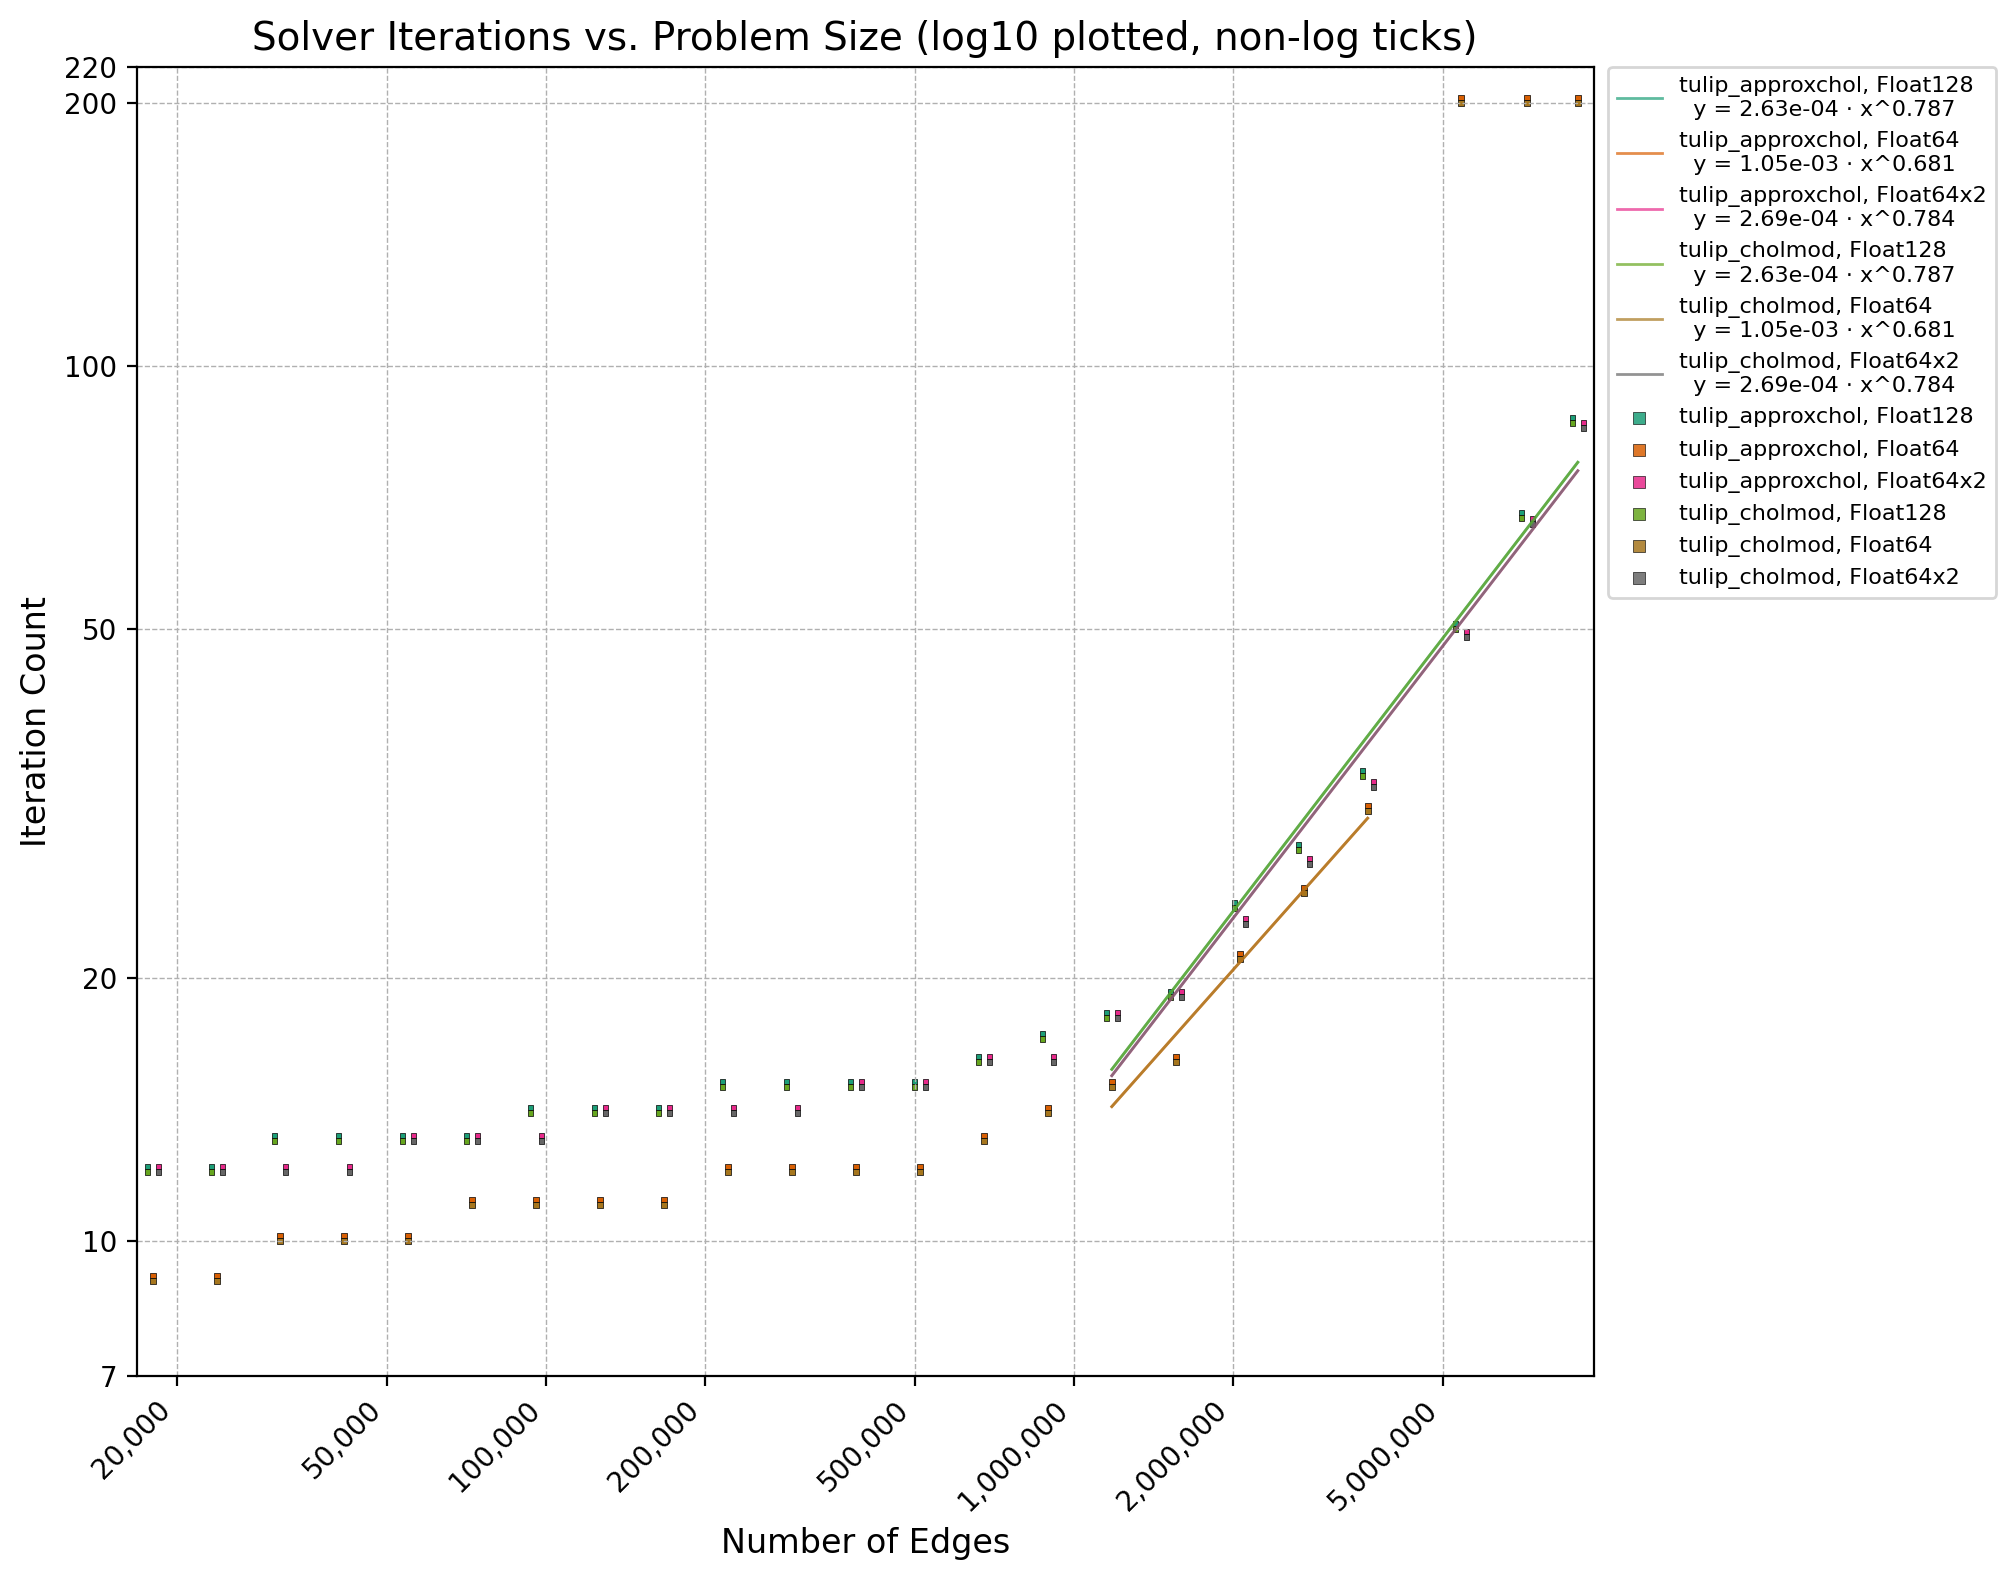

In [115]:
plot_iterations_vs_edges("../unifwidegrid.db")